<p><font size="6" color='grey'> <b>
Machine Learning
</b></font> </br></p>

<p><font size="5" color='grey'> <b>
Unbalanced Data
</b></font> </br></p>



---

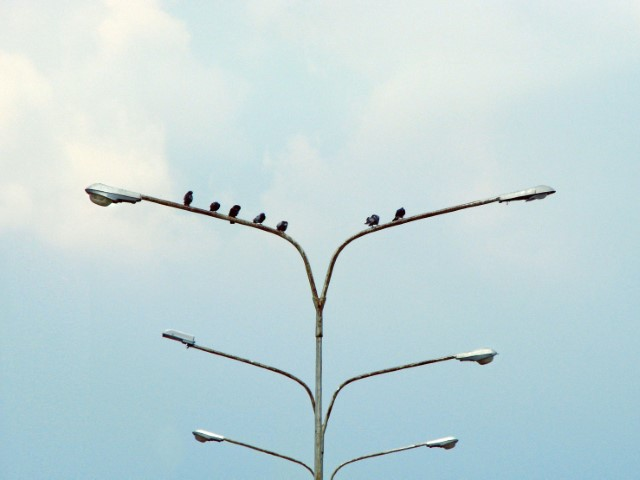

Foto von <a href="https://unsplash.com/de/@eduardoequis?utm_content=creditCopyText&utm_medium=referral&utm_source=unsplash">Eduardo Sánchez</a> auf <a href="https://unsplash.com/de/fotos/sechs-schwarze-vogel-sitzen-auf-einer-strassenlaterne-WXJTpCC_KpA?utm_content=creditCopyText&utm_medium=referral&utm_source=unsplash">Unsplash</a>
  

# **0 <font color='orange'>|</font> Install & Import**
---

In [ ]:
# Install


In [ ]:
# Import
import pandas as pd
import numpy as np

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score

from xgboost import XGBClassifier

from collections import Counter

from imblearn.over_sampling import SMOTE

from yellowbrick.target import class_balance

In [ ]:
# Warnung ausstellen
import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", message="X has feature names, but DecisionTreeClassifier was fitted without feature names")

# **1 <font color='orange'>|</font> Understand**
---

Dies ist ein Glasidentifikationsdatensatz von UCI. Es enthält 10 Attribute einschließlich der ID. Die Antwort ist Glastyp (diskrete 7 Werte)

Attribute Information:

+ RI: refractive index
+ Na: Sodium (unit measurement: weight percent in corresponding oxide, as are + Nattributes 4-10)
+ Mg: Magnesium
+ Al: Aluminum
+ Si: Silicon
+ K: Potassium
+ Ca: Calcium
+ Ba: Barium
+ Fe: Iron


Type of glass: (class attribute)
+ 1 building_windows_float_processed
+ 2 building_windows_non_float_processed
+ 3 vehicle_windows_float_processed
+ 4 vehicle_windows_non_float_processed (none in this database)
+ 5 containers
+ 6 tableware
+ 7 headlamps

[OpenML](https://www.openml.org/search?type=data&status=active&id=43750&sort=runs)

[kaggle](https://www.kaggle.com/datasets/uciml/glass)

In [ ]:
data_id = 43750
df = fetch_openml(parser='auto', target_column='default-target', data_id=data_id)

In [ ]:
data = df.data.copy()
target = data.pop('Type')

In [ ]:
feature_names = data.columns

In [ ]:
counter = Counter(target)
for k,v in counter.items():
    per = v / len(target) * 100
    print('Class=%d, Count=%d, Percentage=%.3f%%' % (k, v, per))

In [ ]:
labels = [int(i) for i in target.unique()]
target = [int(i) for i in target]

In [ ]:
visualizer = class_balance(np.array(target), labels=labels)

# **2 <font color='orange'>|</font> Prepare**
---

<p><font color='black' size="5">
Train-Test-Split
</font></p>

In [ ]:
data_train, data_test, target_train, target_test = train_test_split(data, target, test_size=0.2, random_state=42, stratify=target)

# **3 <font color='orange'>|</font> Model**
---

## **3.1 <font color='orange'>|</font> Modelle o. Anpassung**
---

In [ ]:
# Modell
model = LogisticRegression(max_iter=2000, random_state=42)
model.fit(data_train, target_train)

# Vorhersagen und Bewertung
target_test_pred = model.predict(data_test)
report_lr_pure =classification_report(target_test, target_test_pred, labels=labels, zero_division=0.0)
print(report_lr_pure)
print(f1_lr_pure:= f1_score(target_test, target_test_pred, average='weighted'))

In [ ]:
# Modell
model = DecisionTreeClassifier(random_state=42)
model.fit(data_train, target_train)

# Vorhersagen und Bewertung
target_test_pred = model.predict(data_test)
report_dt_pure = classification_report(target_test, target_test_pred, labels=labels, zero_division=0.0)
print(report_dt_pure)
print(f1_dt_pure:= f1_score(target_test, target_test_pred, average='weighted'))

## **3.2 <font color='orange'>|</font> SMOTE**
---

SMOTE steht für "Synthetic Minority Oversampling Technique" und ist eine Methode zur Behandlung von unausgewogenen Datensätzen im Machine Learning. Diese Technik wird verwendet, um die Anzahl der Fälle in der Minderheitsklasse zu erhöhen, indem synthetische Beispiele generiert werden. Dies hilft, die Klassifikationsleistung von Modellen zu verbessern, die auf unausgewogenen Datensätzen trainiert werden.

In [ ]:
# SMOTE anwenden
smote = SMOTE(k_neighbors=3, random_state=42)
data_train_smote, target_train_smote = smote.fit_resample(data_train, target_train)

In [ ]:
visualizer = class_balance(np.array(target_train), labels=labels)

In [ ]:
visualizer = class_balance(np.array(target_train_smote), labels=labels)

In [ ]:
# Modell trainieren
model = DecisionTreeClassifier(random_state=42)
model.fit(data_train_smote, target_train_smote)

In [ ]:
# Vorhersagen und Bewertung
target_test_pred = model.predict(data_test)
report_dt_smote =classification_report(target_test, target_test_pred, labels=labels, zero_division=0.0)
print(report_dt_smote)
print(f1_dt_smote:= f1_score(target_test, target_test_pred, average='weighted'))

## **3.3 <font color='orange'>|</font> Gewichte Decision Tree**
---

In [ ]:
# Klassen-Gewichte berechnen
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(target_train), y=target_train)
class_weight_dict = {np.unique(target_train)[i]: class_weights[i] for i in range(len(class_weights))}

In [ ]:
# Modell trainieren
model = DecisionTreeClassifier(class_weight=class_weight_dict, random_state=42)
model.fit(data_train, target_train)

In [ ]:
# Vorhersagen und Bewertung
target_test_pred = model.predict(data_test)
report_dtg =classification_report(target_test, target_test_pred, labels=labels, zero_division=0.0)
print(report_dtg)
print(f1_dtg:= f1_score(target_test, target_test_pred, average='weighted'))

## **3.4 <font color='orange'>|</font> Gewichte RandomForest**
---

In [ ]:
# Modell trainieren
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(data_train, target_train)

In [ ]:
# Vorhersagen und Bewertung
target_test_pred = model.predict(data_test)
report_rf =classification_report(target_test, target_test_pred, labels=labels, zero_division=0.0)
print(report_rf)
print(f1_rf:= f1_score(target_test, target_test_pred, average='weighted'))

## **3.5 <font color='orange'>|</font> Ensemble (xgboost)**
---

In [ ]:
# Label Encoder initialisieren
encoder = LabelEncoder()

# Zielvariablen transformieren
target_train_encoded = encoder.fit_transform(target_train)

In [ ]:
# Modell trainieren
model = XGBClassifier(random_state=42)
model.fit(data_train, target_train_encoded)

In [ ]:
# Vorhersagen und Bewertung
target_test_pred = model.predict(data_test)

report_xgboost =classification_report(target_test, encoder.inverse_transform(target_test_pred), labels=labels, zero_division=0.0)
print(report_xgboost)
print(f1_xgboost:= f1_score(target_test, encoder.inverse_transform(target_test_pred), average='weighted'))

## **3.6 <font color='orange'>|</font> Kombi xgboost & SMOTE**
---

In [ ]:
# Label Encoder initialisieren
encoder = LabelEncoder()

# Zielvariablen transformieren
target_train_encoded = encoder.fit_transform(target_train)

In [ ]:
# SMOTE anwenden
smote = SMOTE(k_neighbors=3, random_state=42)
data_train_smote, target_train_smote = smote.fit_resample(data_train, target_train_encoded)

In [ ]:
# Modell trainieren
model = XGBClassifier(random_state=42)
model.fit(data_train_smote, target_train_smote)

In [ ]:
# Vorhersagen und Bewertung
target_test_pred = model.predict(data_test)

report_xgboost_plus =classification_report(target_test, encoder.inverse_transform(target_test_pred), labels=labels, zero_division=0.0)
print(report_xgboost_plus)
print(f1_xgboost_plus:= f1_score(target_test, encoder.inverse_transform(target_test_pred), average='weighted'))

In [ ]:
target_train_pred = model.predict(data_train)

report_xgboost_plus_ =classification_report(target_train, encoder.inverse_transform(target_train_pred), labels=labels, zero_division=0.0)
print(report_xgboost_plus_)
print(f1_score(target_train, encoder.inverse_transform(target_train_pred), average='weighted'))

# **A <font color='orange'>|</font> Appendix**
---

In [ ]:
# f1-score auswerten
report_rf_dic = classification_report(target_test, encoder.inverse_transform(target_test_pred), output_dict=True)
# Dict comprehension to extract f1-scores, filtering out non-numeric keys
f1_scores = {key: value['f1-score'] for key, value in report_rf_dic.items() if key.isdigit()}
print(f1_scores)

In [ ]:
values_list = list(f1_scores.values())
sum(values_list)/len(values_list)